# L'IA générative améliore-t-elle vraiment les performances académiques ?
### Une analyse de 50 000 profils étudiants et une leçon sur le p-hacking

**Auteure :** Steffi TADOGBE
**Dataset :** AI Student Impact Dataset (50 000 étudiants  usage de l'IA générative, GPA avant/après semestre, anxiété, burnout, dépendance perçue)

---

## Contexte

Avec l'adoption massive d'outils comme ChatGPT, Copilot ou Gemini dans la vie étudiante, les établissements scolaires se forgent des avis tranchés:interdire, encadrer, encourager  souvent sans données solides pour appuyer ces décisions.

Ce notebook part d'une question simple : **est-ce que l'usage de l'IA générative améliore réellement la performance académique des étudiants ?**

Mais ce notebook documente aussi une dérive méthodologique que j'ai commise en cours de route  et qui mérite d'être racontée autant que le résultat lui-même.

## 1. Chargement des données

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

df = pd.read_csv('ai_student_impact_dataset.csv')
df['GPA_Change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']

print(f"Nombre d'étudiants : {len(df):,}")
df.head()

Matplotlib is building the font cache; this may take a moment.


Nombre d'étudiants : 50,000


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Change
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163


## 2. Hypothèses (posées AVANT toute exploration des résultats)

Pour rester rigoureuse, je formule mes hypothèses comme dans un test statistique classique, avant d'aller regarder ce que disent les données  pas après.

- **H0 (hypothèse nulle)** : L'usage de l'IA générative n'a pas d'effet positif significatif sur la performance académique (GPA) des étudiants.
- **H1 (hypothèse alternative)** : L'usage de l'IA générative améliore la performance académique des étudiants.

**Variable indépendante :** `Weekly_GenAI_Hours` (heures d'usage hebdomadaire de l'IA)
**Variable dépendante :** `GPA_Change` (Post_Semester_GPA − Pre_Semester_GPA)

## 3. Test de l'hypothèse principale

In [4]:
# Corrélation globale entre heures d'usage et progression du GPA
r, p = stats.pearsonr(df['Weekly_GenAI_Hours'], df['GPA_Change'])
print(f"Corrélation : r = {r:.4f}, p = {p:.6f}")

# Comparaison usage faible vs usage fort (split à la médiane)
median_h = df['Weekly_GenAI_Hours'].median()
low = df[df['Weekly_GenAI_Hours'] <= median_h]['GPA_Change']
high = df[df['Weekly_GenAI_Hours'] > median_h]['GPA_Change']
t, p_t = stats.ttest_ind(high, low)

print(f"\nMédiane d'usage : {median_h}h/semaine")
print(f"GPA_Change moyen (usage faible, n={len(low):,}) : {low.mean():.4f}")
print(f"GPA_Change moyen (usage fort,  n={len(high):,}) : {high.mean():.4f}")
print(f"Écart réel : {high.mean() - low.mean():.4f} point de GPA")
print(f"T-test : t = {t:.4f}, p = {p_t:.6f}")

Corrélation : r = -0.0465, p = 0.000000

Médiane d'usage : 5.8h/semaine
GPA_Change moyen (usage faible, n=25,026) : 0.1968
GPA_Change moyen (usage fort,  n=24,974) : 0.2096
Écart réel : 0.0127 point de GPA
T-test : t = 7.6131, p = 0.000000


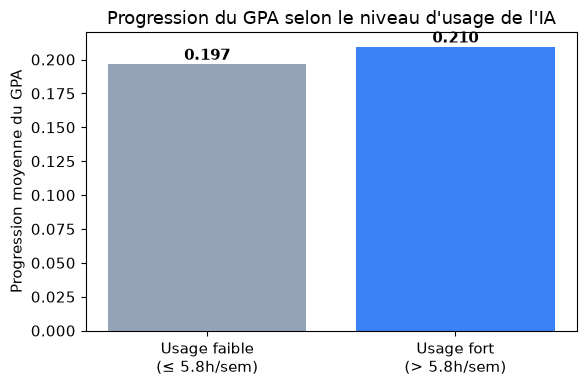

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
means = [low.mean(), high.mean()]
bars = ax.bar(['Usage faible\n(≤ 5.8h/sem)', 'Usage fort\n(> 5.8h/sem)'], means,
              color=['#94a3b8', '#3b82f6'])
ax.set_ylabel('Progression moyenne du GPA')
ax.set_title('Progression du GPA selon le niveau d\'usage de l\'IA')
for bar, val in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.003, f'{val:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Premier constat

Le test est **statistiquement significatif** (p < 0.0001) : la différence n'est très probablement pas due au hasard.

Mais l'écart réel entre les deux groupes est de **0.013 point de GPA**. C'est négligeable en pratique  sur une échelle de 0 à 4, c'est invisible dans la vie réelle d'un étudiant.

**Pourquoi un effet aussi minuscule est-il "significatif" ?** Avec 50 000 lignes, la p-value devient mécaniquement très petite dès qu'il y a la moindre différence entre deux groupes, même négligeable. Il faut distinguer :
- la **significativité statistique** (p-value : "est-ce dû au hasard ?")
- la **taille de l'effet** (l'écart réel : "est-ce que ça compte en vrai ?")

Ici : significatif statistiquement, mais sans portée pratique. **On ne peut pas rejeter H0** sur la base du seul volume d'usage.

## 4. Ce qui s'est passé ensuite 

À ce stade, le résultat me semblait... trop plat pour un post. Alors j'ai continué à tester d'autres variables, en boucle, à la recherche d'un résultat plus marquant : la compétence en prompt engineering, le type d'usage principal, la politique de l'établissement, l'abonnement payant, l'année d'étude, l'anxiété, la rétention des compétences...

Voici un échantillon de ces tests, lancés les uns après les autres sans hypothèse préalable :

In [6]:
# Tests exploratoires lancés "à la pêche"  sans hypothèse formulée à l'avance
tests = []

# Niveau de compétence (prompt engineering)
groups = [df[df['Prompt_Engineering_Skill']==lvl]['GPA_Change'] for lvl in ['Beginner','Intermediate','Advanced']]
f, p1 = stats.f_oneway(*groups)
tests.append(('Prompt_Engineering_Skill vs GPA_Change', p1))

# Type d'usage principal
groups2 = [g['GPA_Change'].values for _, g in df.groupby('Primary_Use_Case')]
f2, p2 = stats.f_oneway(*groups2)
tests.append(('Primary_Use_Case vs GPA_Change', p2))

# Politique institutionnelle
groups3 = [g['GPA_Change'].values for _, g in df.groupby('Institutional_Policy')]
f3, p3 = stats.f_oneway(*groups3)
tests.append(('Institutional_Policy vs GPA_Change', p3))

# Abonnement payant
r4, p4 = stats.pointbiserialr(df['Paid_Subscription'], df['GPA_Change'])
tests.append(('Paid_Subscription vs GPA_Change', p4))

# Anxiété vs rétention des compétences
r5, p5 = stats.pearsonr(df['Anxiety_Level_During_Exams'], df['Skill_Retention_Score'])
tests.append(('Anxiety vs Skill_Retention_Score', p5))

for name, pval in tests:
    flag = "→ p < 0.05" if pval < 0.05 else "→ ns"
    print(f"{name:45s} p = {pval:.2e}  {flag}")

Prompt_Engineering_Skill vs GPA_Change        p = 7.15e-242  → p < 0.05
Primary_Use_Case vs GPA_Change                p = 0.00e+00  → p < 0.05
Institutional_Policy vs GPA_Change            p = 8.19e-21  → p < 0.05
Paid_Subscription vs GPA_Change               p = 1.13e-04  → p < 0.05
Anxiety vs Skill_Retention_Score              p = 1.46e-20  → p < 0.05


## 5. Ce que je viens de faire, et pourquoi c'est un problème

Ce que montre la cellule au-dessus, c'est presque tout qui ressort "significatif"  sans surprise vu la taille de l'échantillon (cf. section 3). Le vrai problème n'est pas dans les chiffres, il est dans **ma démarche** : j'ai testé variable après variable, sans hypothèse préalable, jusqu'à tomber sur quelque chose qui "sonnait bien" pour un post LinkedIn.

Ça porte un nom : le **p-hacking** (ou *data dredging*, "pêche aux résultats"). C'est un biais bien documenté en analyse de données et en recherche :

> Si on teste suffisamment de combinaisons de variables sur un même jeu de données, on finit presque toujours par trouver "quelque chose de significatif"  par pur hasard statistique, pas parce que c'est un vrai phénomène.

C'est l'inverse d'une autre erreur qu'on évite généralement (formuler une hypothèse *après* avoir vu le résultat, pour qu'elle colle parfaitement)  mais le résultat est le même : une histoire qui a l'air rigoureuse, alors qu'elle a été construite à l'envers.

**La bonne pratique** : une fois l'hypothèse principale testée (section 3), on s'arrête. Si un résultat secondaire semble intéressant, il doit être présenté comme une **piste à creuser avec sa propre étude dédiée**  pas comme une découverte validée.

## 6. Conclusion

**Sur l'hypothèse de départ (H0 vs H1) :**
On ne peut pas rejeter H0. Le volume d'usage de l'IA générative, à lui seul, n'a pas d'effet de taille pratique sur la progression du GPA dans ce dataset  malgré une p-value très faible due à la taille de l'échantillon.

**Sur la démarche :**
Cette analyse illustre concrètement pourquoi un data analyst doit fixer son hypothèse *avant* d'explorer les données, et s'y tenir  même quand le résultat est "plat". Multiplier les tests à la recherche d'un résultat marquant n'est pas une faute rare ou réservée aux débutants : c'est une tentation constante, surtout quand on doit produire un contenu ou une conclusion attrayante. La rigueur consiste justement à reconnaître ce moment et à s'arrêter.

**Piste pour une future étude (pas une conclusion ici) :**
Le test exploratoire sur `Institutional_Policy` suggère une différence entre politiques d'interdiction stricte et politiques plus permissives, à creuser avec sa propre hypothèse pré-définie, indépendamment de cette analyse.

---
*Dataset : AI Student Impact Dataset · Analyse : Steffi Tadogbe*